In [13]:
import sys, time, random
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
import torchvision, torchvision.transforms as T
from torch.utils.data import DataLoader, Subset, random_split

try:
    import cv2
    print("OpenCV:", cv2.__version__)
except ImportError:
    cv2 = None
    print("OpenCV not found (only needed for the optional photo test)")

SEED = 42  # fixed seed so your results are repeatable
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__, "| torchvision:", torchvision.__version__)
print("Training on:", device)

OpenCV: 4.11.0
Python: 3.12.4
PyTorch: 2.9.1 | torchvision: 0.24.1
Training on: mps


In [15]:
CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
'dog', 'frog', 'horse', 'ship', 'truck']
MEAN, STD = (0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)
tf = T.Compose([T.ToTensor(), T.Normalize(MEAN, STD)])
train_full = torchvision.datasets.CIFAR10("./data", train=True, download=True, transform=tf)
test_set = torchvision.datasets.CIFAR10("./data", train=False, download=True, transform=tf)
# 45,000 for training, 5,000 for validation
train_set, val_set = random_split(
train_full, [45000, 5000], generator=torch.Generator().manual_seed(SEED))
BATCH = 128
train_loader = DataLoader(train_set, batch_size=BATCH, shuffle=True, num_workers=2)
val_loader = DataLoader(val_set, batch_size=BATCH, shuffle=False, num_workers=2)
test_loader = DataLoader(test_set, batch_size=BATCH, shuffle=False, num_workers=2)
print("train / val / test sizes:", len(train_set), len(val_set), len(test_set))

100%|█████████████████████████████████████████████████████████████████████████████| 170M/170M [33:38<00:00, 84.5kB/s]


train / val / test sizes: 45000 5000 10000


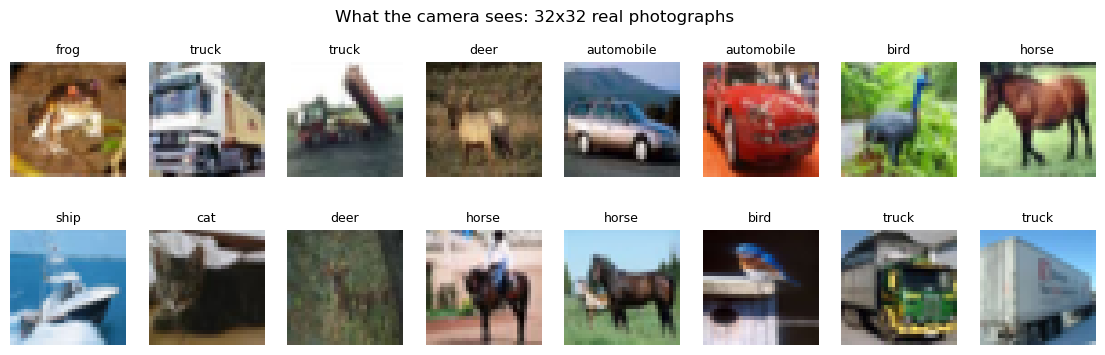

Images per class: {'airplane': 5000, 'automobile': 5000, 'bird': 5000, 'cat': 5000, 'deer': 5000, 'dog': 5000, 'frog': 5000, 'horse': 5000, 'ship': 5000, 'truck': 5000}


In [22]:
raw = torchvision.datasets.CIFAR10("./data", train=True, download=False)  # PIL images

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for ax, i in zip(axes.flat, range(16)):
    img, label = raw[i]
    ax.imshow(img)
    ax.set_title(CLASSES[label], fontsize=9)
    ax.axis("off")
plt.suptitle("What the camera sees: 32x32 real photographs")
plt.show()

print("Images per class:", dict(zip(CLASSES, np.bincount(raw.targets))))

In [24]:
images, labels = next(iter(train_loader))
print("images:", images.shape, "| labels:", labels.shape)
print("pixel range after normalisation: %.2f to %.2f" % (images.min(), images.max()))

images: torch.Size([128, 3, 32, 32]) | labels: torch.Size([128])
pixel range after normalisation: -1.99 to 2.13


In [28]:
class SceneCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256), nn.ReLU(),
            nn.Linear(256, num_classes),     # raw scores (logits), no softmax here
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = SceneCNN().to(device)
print(model)

SceneCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [32]:
x = torch.randn(1, 3, 32, 32).to(device)       # one fake 32x32 colour image
for layer in model.features:
    x = layer(x)
    print(f"{layer.__class__.__name__:<10} -> {tuple(x.shape)}")
print("Flattened length fed to the classifier:", x.numel())

Conv2d     -> (1, 32, 32, 32)
ReLU       -> (1, 32, 32, 32)
MaxPool2d  -> (1, 32, 16, 16)
Conv2d     -> (1, 64, 16, 16)
ReLU       -> (1, 64, 16, 16)
MaxPool2d  -> (1, 64, 8, 8)
Conv2d     -> (1, 128, 8, 8)
ReLU       -> (1, 128, 8, 8)
MaxPool2d  -> (1, 128, 4, 4)
Flattened length fed to the classifier: 2048


In [36]:
def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

mlp = nn.Sequential(nn.Flatten(), nn.Linear(3 * 32 * 32, 1024), nn.ReLU(), nn.Linear(1024, 10))

print(f"SceneCNN parameters : {count_params(model):>10,}")
print(f"Plain MLP parameters: {count_params(mlp):>10,}")
print()
for name, p in model.named_parameters():
    print(f"{name:<22}{str(tuple(p.shape)):<20}{p.numel():>9,}")

SceneCNN parameters :    620,362
Plain MLP parameters:  3,157,002

features.0.weight     (32, 3, 3, 3)             864
features.0.bias       (32,)                      32
features.3.weight     (64, 32, 3, 3)         18,432
features.3.bias       (64,)                      64
features.6.weight     (128, 64, 3, 3)        73,728
features.6.bias       (128,)                    128
classifier.1.weight   (256, 2048)           524,288
classifier.1.bias     (256,)                    256
classifier.3.weight   (10, 256)               2,560
classifier.3.bias     (10,)                      10


In [40]:
layers = [("conv1", 3, 1), ("pool1", 2, 2), ("conv2", 3, 1),
          ("pool2", 2, 2), ("conv3", 3, 1), ("pool3", 2, 2)]   # (name, kernel, stride)

# My prediction: ...
r, j = 1, 1
for name, k, s in layers:
    r = r + (k - 1) * j
    j = j * s
    print(f"{name}: each neuron sees a {r} x {r} patch of the original image")

conv1: each neuron sees a 3 x 3 patch of the original image
pool1: each neuron sees a 4 x 4 patch of the original image
conv2: each neuron sees a 8 x 8 patch of the original image
pool2: each neuron sees a 10 x 10 patch of the original image
conv3: each neuron sees a 18 x 18 patch of the original image
pool3: each neuron sees a 22 x 22 patch of the original image


In [42]:
criterion = nn.CrossEntropyLoss()

images, labels = next(iter(train_loader))
images, labels = images.to(device), labels.to(device)

model.zero_grad()
loss = criterion(model(images), labels)   # forward pass + loss
loss.backward()                           # backward pass (backpropagation)

print(f"Initial loss: {loss.item():.3f}  (guessing = ln(10) = {np.log(10):.3f})")
for name, p in model.named_parameters():
    if "weight" in name:
        print(f"{name:<22} gradient norm = {p.grad.norm().item():.4f}")

Initial loss: 2.300  (guessing = ln(10) = 2.303)
features.0.weight      gradient norm = 0.0171
features.3.weight      gradient norm = 0.0652
features.6.weight      gradient norm = 0.0953
classifier.1.weight    gradient norm = 0.2220
classifier.3.weight    gradient norm = 0.0808


In [44]:
EPOCHS = 8 if device.type != "cpu" else 4     # fewer epochs on CPU
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

def run_epoch(loader, train):
    model.train(train)
    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)                    # forward pass
            loss = criterion(out, y)          # cross-entropy loss
            if train:
                optimizer.zero_grad()
                loss.backward()               # backpropagation
                optimizer.step()              # gradient descent step
            total_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            n += x.size(0)
    return total_loss / n, correct / n

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tl, ta = run_epoch(train_loader, train=True)
    vl, va = run_epoch(val_loader, train=False)
    for k, v in zip(history, (tl, vl, ta, va)):
        history[k].append(v)
    print(f"Epoch {epoch}/{EPOCHS} | train loss {tl:.3f} acc {ta:.1%} "
          f"| val loss {vl:.3f} acc {va:.1%} | {time.time() - t0:.0f}s")

Epoch 1/8 | train loss 1.781 acc 34.8% | val loss 1.474 acc 46.6% | 32s
Epoch 2/8 | train loss 1.286 acc 53.8% | val loss 1.145 acc 58.3% | 30s
Epoch 3/8 | train loss 1.043 acc 63.1% | val loss 0.983 acc 64.6% | 32s
Epoch 4/8 | train loss 0.868 acc 69.4% | val loss 0.853 acc 70.1% | 31s
Epoch 5/8 | train loss 0.746 acc 74.0% | val loss 0.782 acc 72.4% | 31s
Epoch 6/8 | train loss 0.640 acc 77.6% | val loss 0.798 acc 72.3% | 31s
Epoch 7/8 | train loss 0.558 acc 80.3% | val loss 0.750 acc 74.2% | 31s
Epoch 8/8 | train loss 0.478 acc 83.2% | val loss 0.768 acc 74.2% | 31s


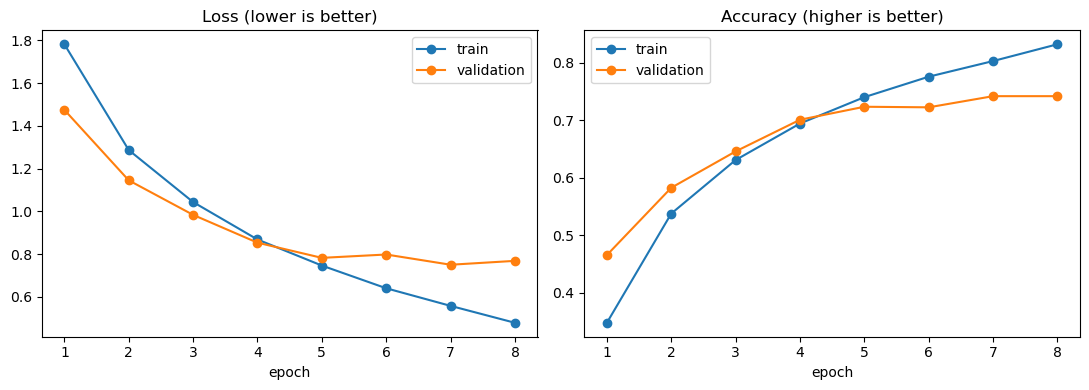

In [45]:
epochs = range(1, len(history["train_loss"]) + 1)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].plot(epochs, history["train_loss"], "o-", label="train")
ax[0].plot(epochs, history["val_loss"], "o-", label="validation")
ax[0].set_title("Loss (lower is better)"); ax[0].set_xlabel("epoch"); ax[0].legend()

ax[1].plot(epochs, history["train_acc"], "o-", label="train")
ax[1].plot(epochs, history["val_acc"], "o-", label="validation")
ax[1].set_title("Accuracy (higher is better)"); ax[1].set_xlabel("epoch"); ax[1].legend()

plt.tight_layout(); plt.show()
torch.save(model.state_dict(), "scene_cnn_week3.pth")

Test accuracy: 74.27%

airplane   87.2%
automobile 82.6%
bird       63.2%
cat        51.7%
deer       66.8%
dog        62.2%
frog       81.4%
horse      83.6%
ship       87.1%
truck      76.9%


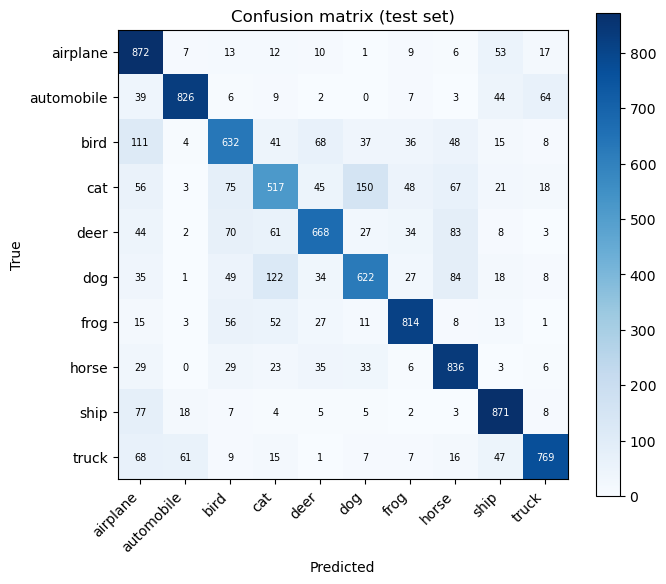


Three most common mistakes:
  cat predicted as dog: 150 times
  dog predicted as cat: 122 times
  bird predicted as airplane: 111 times


In [48]:
@torch.no_grad()
def predict_all(loader):
    model.eval()
    probs, ys = [], []
    for x, y in loader:
        probs.append(F.softmax(model(x.to(device)), dim=1).cpu())
        ys.append(y)
    return torch.cat(probs), torch.cat(ys)

probs, ys = predict_all(test_loader)
preds = probs.argmax(1)
print(f"Test accuracy: {(preds == ys).float().mean():.2%}\n")

cm = np.zeros((10, 10), dtype=int)            # rows = true, cols = predicted
for t, p_ in zip(ys.numpy(), preds.numpy()):
    cm[t, p_] += 1

for c, a in zip(CLASSES, cm.diagonal() / cm.sum(1)):
    print(f"{c:<11}{a:.1%}")

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(10)); ax.set_xticklabels(CLASSES, rotation=45, ha="right")
ax.set_yticks(range(10)); ax.set_yticklabels(CLASSES)
ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title("Confusion matrix (test set)")
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=7,
                color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im); plt.tight_layout(); plt.show()

off = cm.copy(); np.fill_diagonal(off, 0)     # keep only the mistakes
print("\nThree most common mistakes:")
for idx in np.argsort(-off.ravel())[:3]:
    t, p_ = divmod(idx, 10)
    print(f"  {CLASSES[t]} predicted as {CLASSES[p_]}: {off[t, p_]} times")

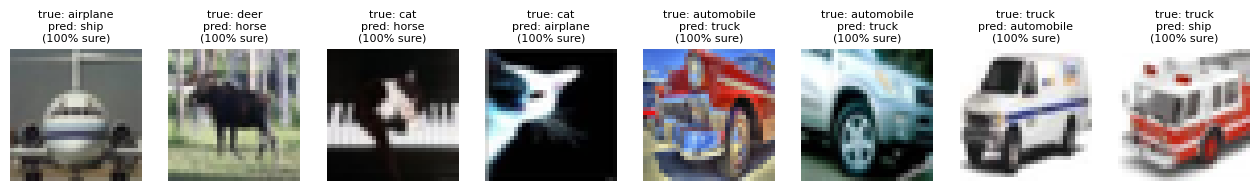

In [50]:
conf, _ = probs.max(1)
wrong = (preds != ys).nonzero().flatten()
worst = wrong[conf[wrong].argsort(descending=True)[:8]]

raw_test = torchvision.datasets.CIFAR10("./data", train=False, download=False)
fig, axes = plt.subplots(1, 8, figsize=(16, 3))
for ax, idx in zip(axes, worst.tolist()):
    img, _ = raw_test[idx]
    ax.imshow(img); ax.axis("off")
    ax.set_title(f"true: {CLASSES[ys[idx]]}\npred: {CLASSES[preds[idx]]}\n({conf[idx]:.0%} sure)",
                 fontsize=8)
plt.show()

In [52]:
VEHICLES = torch.tensor([0, 1, 8, 9])         # airplane, automobile, ship, truck
true_vehicle = torch.isin(ys, VEHICLES)
pred_vehicle = torch.isin(preds, VEHICLES)

print(f"10-class (object-level) accuracy : {(preds == ys).float().mean():.2%}")
print(f"Vehicle vs animal (scene-level)  : {(true_vehicle == pred_vehicle).float().mean():.2%}")

10-class (object-level) accuracy : 74.27%
Vehicle vs animal (scene-level)  : 94.16%


In [54]:
def out_size(h, k, p, s):
    return (h + 2 * p - k) // s + 1

for k, p_, s in [(3, 0, 1), (3, 0, 2), (3, 1, 1), (3, 1, 2)]:
    real = nn.Conv2d(3, 8, kernel_size=k, padding=p_, stride=s)(torch.randn(1, 3, 32, 32))
    print(f"kernel={k} padding={p_} stride={s}: formula {out_size(32, k, p_, s)}"
          f" | PyTorch {real.shape[-1]}")

kernel=3 padding=0 stride=1: formula 30 | PyTorch 30
kernel=3 padding=0 stride=2: formula 15 | PyTorch 15
kernel=3 padding=1 stride=1: formula 32 | PyTorch 32
kernel=3 padding=1 stride=2: formula 16 | PyTorch 16


In [56]:
sub_loader = DataLoader(Subset(train_set, range(10000)), batch_size=BATCH,
                        shuffle=True, num_workers=2)

def quick_lr_test(lr, epochs=2):
    torch.manual_seed(SEED)
    m = SceneCNN().to(device)
    opt = torch.optim.SGD(m.parameters(), lr=lr, momentum=0.9)
    for _ in range(epochs):
        m.train()
        for x, y in sub_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            loss = criterion(m(x), y)
            loss.backward()
            opt.step()
    m.eval(); correct = 0
    with torch.no_grad():
        for x, y in val_loader:
            correct += (m(x.to(device)).argmax(1).cpu() == y).sum().item()
    return loss.item(), correct / len(val_set)

# My prediction: ...
for lr in [0.1, 0.01, 0.001]:
    last_loss, val_acc = quick_lr_test(lr)
    print(f"lr = {lr:<6} final batch loss = {last_loss:.3f}  validation accuracy = {val_acc:.1%}")

lr = 0.1    final batch loss = 1.613  validation accuracy = 38.5%
lr = 0.01   final batch loss = 1.725  validation accuracy = 38.5%
lr = 0.001  final batch loss = 2.299  validation accuracy = 12.4%


In [72]:
import os
print(os.getcwd())      # the folder your notebook is working in
print(os.listdir())     # the files already in that folder

/Users/marufi
['Unity user templates', '.config', 'Music', '.zprofile.pysave', '.skiko', '.condarc', '.copilot', 'Untitled1.ipynb', '.DS_Store', 'pythone.py', '.plastic4', '.vscode-shared', '.CFUserTextEncoding', '.wget-hsts', '.xonshrc', 'yolo11n.pt', 'Untitled3.ipynb', 'Untitled.ipynb', '.zshrc', 'week3CNN.ipynb', 'Untitled4.ipynb', '.local', 'Pictures', 'show_faces.py', 'unity 3D.rtf', 'My project', '.zprofile', 'Week3_CNN_Lab', 'health informatics', 'My project (2)', '.zsh_history', 'Untitled2.ipynb', '.ipython', '.anaconda-desktop', 'Desktop', 'Library', '.matplotlib', 'models', 'My project (1)', 'iCloud Drive (Archive)', '.spyder-py3', 'week2_assignment', '.mamba', '.codex', 'Public', 'handtracker.py', 'rasaenv', '.idlerc', 'marufi_chatbot', '.tcshrc', '.virtual_documents', 'kdu_chatbot', '.anaconda', 'Movies', 'Applications', '.profile', 'tracking', '.Trash', 'heath informatics', '.ipynb_checkpoints', '.jupyter', '.keras', 'Documents', 'venv', 'untitled2.py', 'rasa init\n', '.vs

In [78]:
%pip install -q pillow-avif-plugin

Note: you may need to restart the kernel to use updated packages.


In [80]:
import os
print(os.getcwd())
print(os.path.exists("animal.jpg"))
with open("animal.jpg", "rb") as f:
    print(f.read(16))

/Users/marufi
True
b'\x00\x00\x00\x1cftypavif\x00\x00\x00\x00'


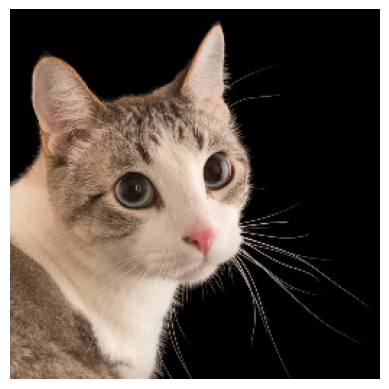

cat        82.2%
horse      15.7%
dog        1.9%


In [90]:
import numpy as np
from PIL import Image
import pillow_avif  # lets PIL open AVIF images

def predict_photo(path, topk=3):
    rgb = np.array(Image.open(path).convert("RGB"))
    h, w = rgb.shape[:2]; s = min(h, w)             # centre square crop
    rgb = rgb[(h - s) // 2:(h - s) // 2 + s, (w - s) // 2:(w - s) // 2 + s]
    small = cv2.resize(rgb, (32, 32), interpolation=cv2.INTER_AREA)
    x = torch.from_numpy(small).permute(2, 0, 1).float() / 255.0
    x = T.Normalize(MEAN, STD)(x).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        p_ = F.softmax(model(x), dim=1)[0].cpu()
    top = p_.topk(topk)
    plt.imshow(cv2.resize(rgb, (256, 256))); plt.axis("off"); plt.show()
    for score, i in zip(top.values, top.indices):
        print(f"{CLASSES[i]:<11}{score:.1%}")

predict_photo("catt.jpg")